# HW02-2：房地产上市公司财务特征分析

- 姓名：王振宇
- [教师作业页面](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)
- GitHub 仓库：https://github.com/CLUD-88/FinEco-hw；[HW02-1 目录](https://github.com/CLUD-88/FinEco-hw/tree/main/hw02-1)；[HW02-2 目录](https://github.com/CLUD-88/FinEco-hw/tree/main/hw02-2)
- 数据来源：CSMAR（中山大学授权下载）；下载文件名、字段及筛选条件见下文；本地整理日期：2026-09-23；样本期间：2005—2015 年，另用 2004 年年末余额。
- AI 使用声明：使用 OpenAI Codex 辅助字段核对、代码编写与初稿核验；具体使用记录见文末。本人提交前仍需复核原始字段、统计口径、图形、解释与复现过程。

本题根据逐年行业及产权记录构建房地产 A 股公司—年度非平衡面板，比较企业数量、产权结构和六项财务指标。指标先在公司层面计算，再按年份求均值和中位数；所有比率使用合并报表。报告将短期借款和长期借款之和用作 `bankloan` 的代理变量，并在解释中保留它与严格“银行贷款”定义的差异。

## 1. 数据来源、样本与变量口径

**分析思路。** 以 `STK_LISTEDCOINFOANL` 中当年房地产行业记录为年度母样本，排除 B 股代码，按公司代码与年度匹配产权和合并财务报表。年度公司数始终以母样本去重统计，不因财务指标缺失删公司。

- 原始文件：`STK_LISTEDCOINFOANL.csv`（上市公司基本信息年度表）、`EN_EquityNatureAll.csv`（股权性质）、两份 `FS_Combas.csv`（资产负债表）、`FS_Comins.csv`（利润表）。均来自工作目录上层的 CSMAR 下载文件夹；字段说明见每个文件夹中的 `[DES][csv].txt`。
- 筛选：`EndDate` 为 2005—2015 年末；行业名称含“房地产”，早期 `J01/J05/J0901` 与后期 `K70` 保留并列明；A 股代码以 `0/3/6` 开头；财务报告期为 12 月 31 日且 `Typrep=A`（合并报表）。
- 产权：`EquityNatureID=1` 国有，`=2` 民营，`=3/4` 或混合编码为其他，空值为产权不明。非国有不直接等于民营。
- **局限：** CSMAR 本次下载的 `LISTINGSTATE` 字段说明为“已出年报最新的股票状态”，不能独立证明各历史年末的上市状态。因此用当年年度公司记录、上市日期及 A 股代码构造年度样本；严格的逐年退市日期仍需另行核验。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
DATA = Path('data')
panel = pd.read_csv(DATA / 'panel_restricted.csv', dtype={'code': str})
flow = pd.read_csv(DATA / 'sample_flow.csv')
metrics = {
    'asset_liability_ratio': '资产负债率', 'bankloan': '借款占总负债比',
    'short_liability_share': '流动负债占比', 'ROA': 'ROA',
    'ROE': 'ROE', 'Cash_TA': 'Cash_TA',
}
display(flow)
print('主键重复数:', panel.duplicated(['code', 'year']).sum())
print('行业代码:', sorted(panel.IndustryCode.dropna().unique()))
print('产权类型:', panel.ownership.value_counts().to_dict())

,step,firm_years,firms
0,年度上市公司原始记录,22818,2893
1,当年房地产行业,1197,175
2,剔除 B 股、保留 A 股代码,1176,170
3,合并产权信息（保留产权缺失）,1176,170
4,匹配当年及上年合并资产负债表,1176,170
5,匹配借款与年度合并净利润,1176,170
6,完成六项指标（缺失保留）,1176,170


主键重复数: 0
行业代码: ['J01', 'J05', 'J0901', 'K70']
产权类型: {'国有': 575, '民营': 489, '其他': 95, '产权不明': 17}


**结果解读。** 原年度上市公司信息有 22,818 条公司—年度记录；按当年房地产行业筛得 1,197 条，剔除 B 股后有 **170 家 A 股公司、1,176 条公司—年度记录**。合并产权与财务信息后保持原样本数，说明不会因财务匹配直接丢失公司。旧行业代码和新代码同时出现，必须按各年记录判断，不能用当前行业反推历史。

- 公司—年度主键无重复；合并使用一对一验证。
- 17 条产权记录为空，仍计入年度公司总数。
- 10 条记录缺少上一年合并资产或权益，影响 ROA、ROE，但不影响公司数量。

### 原始字段与分析变量对应

| 分析变量 | 原始字段 | 计算口径 |
|---|---|---|
| 资产负债率 | `A002000000`, `A001000000` | 总负债 / 总资产 |
| `bankloan` | `A002101000`, `A002201000`, `A002000000` | (短期借款 + 长期借款) / 总负债 |
| 短期负债占比 | `A002100000`, `A002000000` | 流动负债 / 总负债 |
| ROA | `B002000000`, 本年与上年 `A001000000` | 合并净利润 / 平均总资产 |
| ROE | `B002000000`, 本年与上年 `A003000000` | 合并净利润 / 平均所有者权益；平均权益≤0时缺失 |
| `Cash_TA` | `A001101000`, `A001000000` | 货币资金 / 总资产 |

上述金额单位均为人民币元，六项指标均为无量纲比率。`A002101000` 的说明是“一年期以下借款”，`A002201000` 是“向银行或其他金融机构借入的长期借款”；**两者不等于纯银行贷款**。根据本次作业的已确认方案，此处使用两项借款作为 `bankloan` 代理，结果必须按该代理口径解释。缺失值不填零，分母≤0的比率记为缺失；负平均权益不生成可能误导的 ROE。

## 2. 房地产公司数量与产权结构

**分析思路。** 逐年统计母样本去重公司数及国有、民营、其他、产权不明四类。国有和民营占比分母统一为当年房地产 A 股总数。

- 核对四类之和等于总公司数。
- 产权比例和可能低于 100%，因为其他及不明单独保留。

ownership,国有,民营,其他,产权不明,总数,国有占比,民营占比
year,,,,,,,
2005,36,23,2,1,62,0.581,0.371
2006,38,24,3,1,66,0.576,0.364
2007,37,31,4,2,74,0.500,0.419
2008,41,36,5,2,84,0.488,0.429
2009,47,43,5,1,96,0.490,0.448
2010,60,54,8,1,123,0.488,0.439
2011,59,57,11,1,128,0.461,0.445
2012,67,60,14,1,142,0.472,0.423
2013,63,56,15,1,135,0.467,0.415


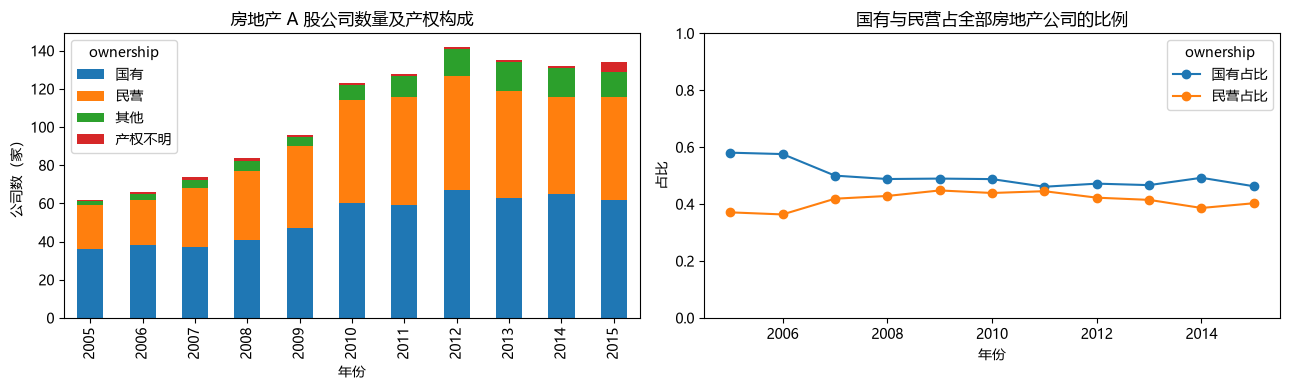

In [2]:
counts = (panel.groupby(['year', 'ownership'])['code'].nunique()
          .unstack(fill_value=0).reindex(columns=['国有', '民营', '其他', '产权不明'], fill_value=0))
counts['总数'] = panel.groupby('year')['code'].nunique()
assert (counts[['国有', '民营', '其他', '产权不明']].sum(axis=1) == counts['总数']).all()
counts['国有占比'] = counts['国有'] / counts['总数']
counts['民营占比'] = counts['民营'] / counts['总数']
display(counts.round(3))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts[['国有', '民营', '其他', '产权不明']].plot.bar(stacked=True, ax=axes[0])
axes[0].set(title='房地产 A 股公司数量及产权构成', xlabel='年份', ylabel='公司数（家）')
counts[['国有占比', '民营占比']].plot(marker='o', ax=axes[1])
axes[1].set(title='国有与民营占全部房地产公司的比例', xlabel='年份', ylabel='占比')
axes[1].set_ylim(0, 1)
fig.tight_layout()
plt.show()

**结果解读。** 样本公司数从 **2005 年的 62 家**升至 **2015 年的 134 家**，2012 年达到 142 家后有所回落。国有公司从 36 家增至 62 家，民营公司从 23 家增至 54 家。数量变化可以由上市、退市或当年行业分类变化共同造成，不能仅凭该表拆分原因。

- 产权类别没有被压成“国有/非国有”二分；其他和产权不明仍在分母中。
- 2005 年国有占 36/62≈58.1%，2015 年为 62/134≈46.3%，显示该样本中的国有份额下降。

## 3. 六项财务指标的年度变化与产权组比较

**分析思路。** 先计算每家企业的比率，再分别对当年有效值求算术均值、中位数和有效样本量。国有、民营只用当年产权分类进入组别比较；其他与不明仍计入总体图。均值可能受极端比率影响，所以同时呈现中位数。

- 每项指标分别保留自己的有效样本，不做全指标共同删行。
- 图中的比例是无量纲值（例如 0.60 表示 60%）。

,资产负债率,借款占总负债比,流动负债占比,ROA,ROE,Cash_TA
year,,,,,,
2005,62,62,62,62,59,62
2006,66,66,66,64,62,66
2007,74,74,74,71,69,74
2008,84,83,84,83,81,84
2009,96,96,96,94,92,96
2010,123,123,123,123,121,123
2011,128,127,128,128,126,128
2012,142,142,142,142,140,142
2013,135,135,135,135,135,135


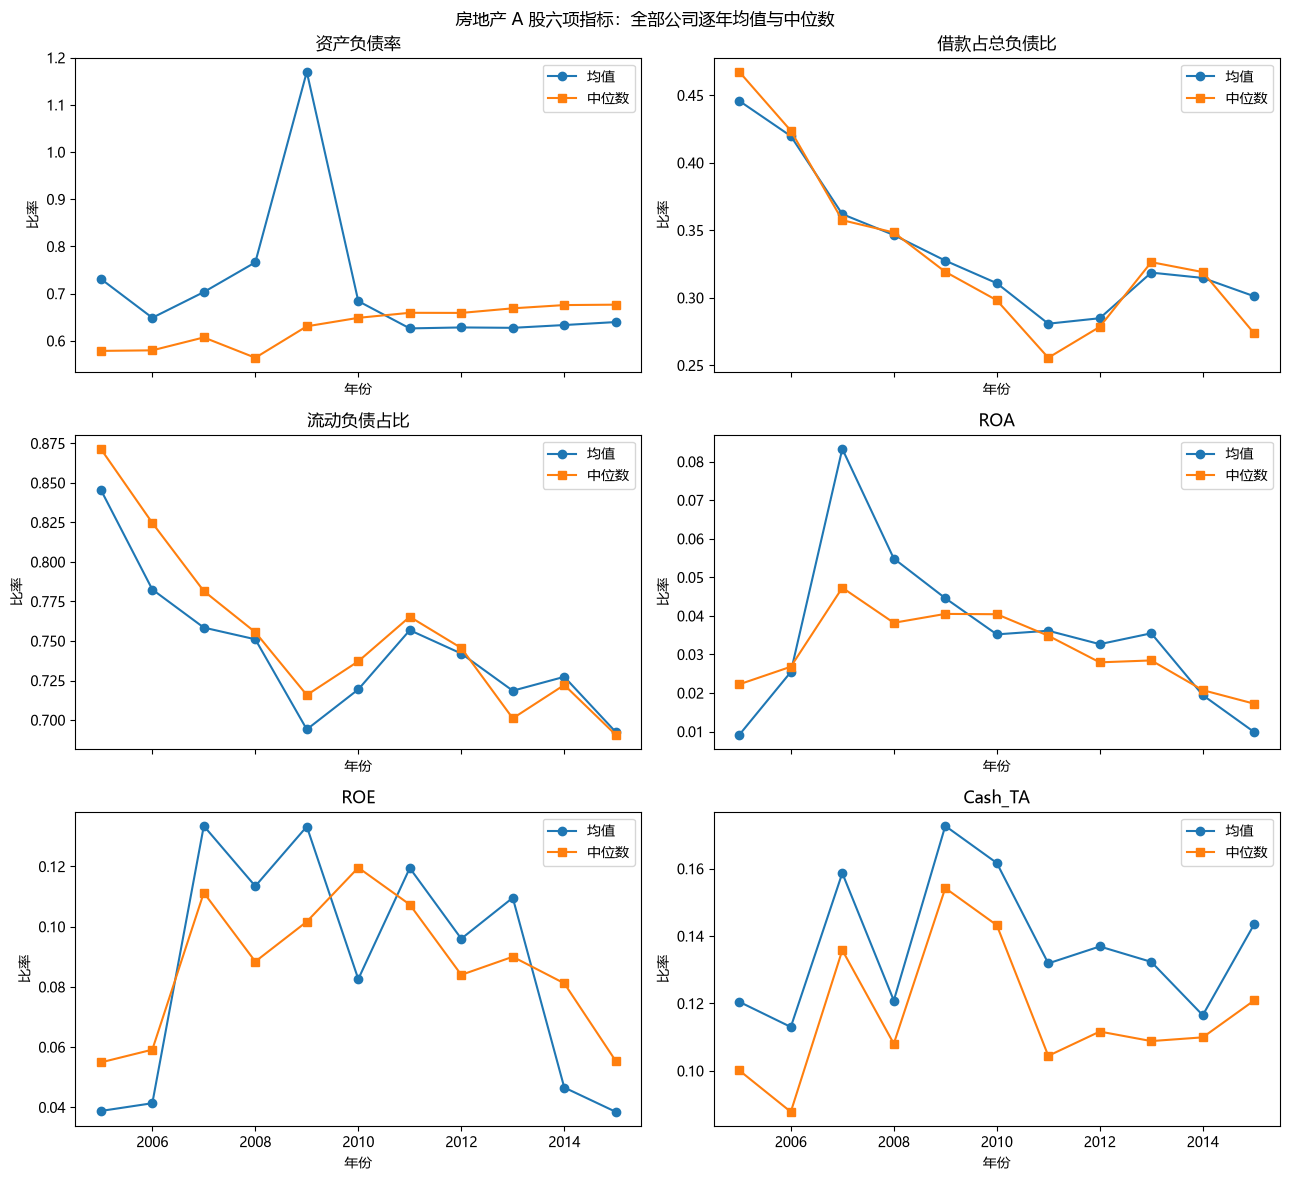

In [3]:
annual_mean = panel.groupby('year')[list(metrics)].mean()
annual_median = panel.groupby('year')[list(metrics)].median()
annual_n = panel.groupby('year')[list(metrics)].count()
display(annual_n.rename(columns=metrics))
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=True)
for ax, (key, title) in zip(axes.flat, metrics.items()):
    ax.plot(annual_mean.index, annual_mean[key], marker='o', label='均值')
    ax.plot(annual_median.index, annual_median[key], marker='s', label='中位数')
    ax.set(title=title, ylabel='比率', xlabel='年份')
    ax.legend()
fig.suptitle('房地产 A 股六项指标：全部公司逐年均值与中位数')
fig.tight_layout()
plt.show()

资产负债率  借款占总负债比  流动负债占比  ROA  ROE  Cash_TA
year ownership                                           
2005 国有            36       36      36   36   35       36
     民营            23       23      23   23   22       23
2006 国有            38       38      38   36   36       38
     民营            24       24      24   24   23       24
2007 国有            37       37      37   36   36       37
     民营            31       31      31   29   28       31
2008 国有            41       40      41   41   41       41
     民营            36       36      36   35   34       36
2009 国有            47       47      47   47   47       47
     民营            43       43      43   41   39       43
2010 国有            60       60      60   60   60       60
     民营            54       54      54   54   52       54
2011 国有            59       59      59   59   59       59
     民营            57       56      57   57   55       57
2012 国有            67       67      67   67   67       67
     民营            60       60      60   60   58       60
2013 国有            63       63      63   63   63       63
     民营            56       56      56   56   56       56
2014 国有            65       65      65   65   65       65
     民营            51       51      51   51   51       51
2015 国有            62       62      62   61   60       62
     民营            54       54      54   53   53       54

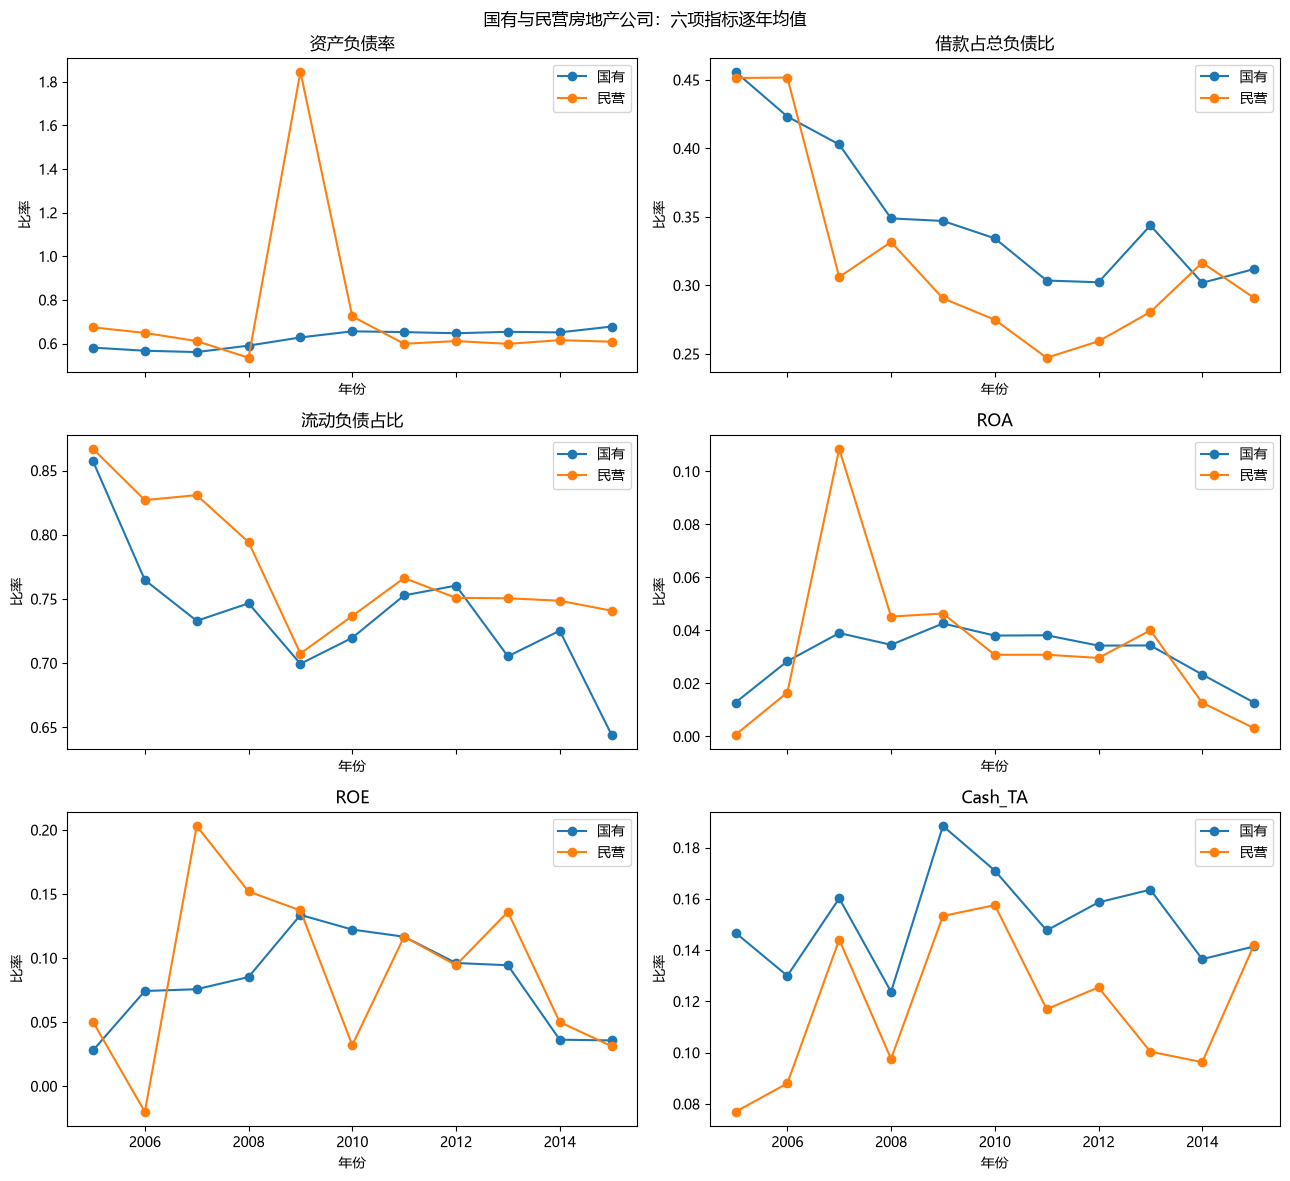

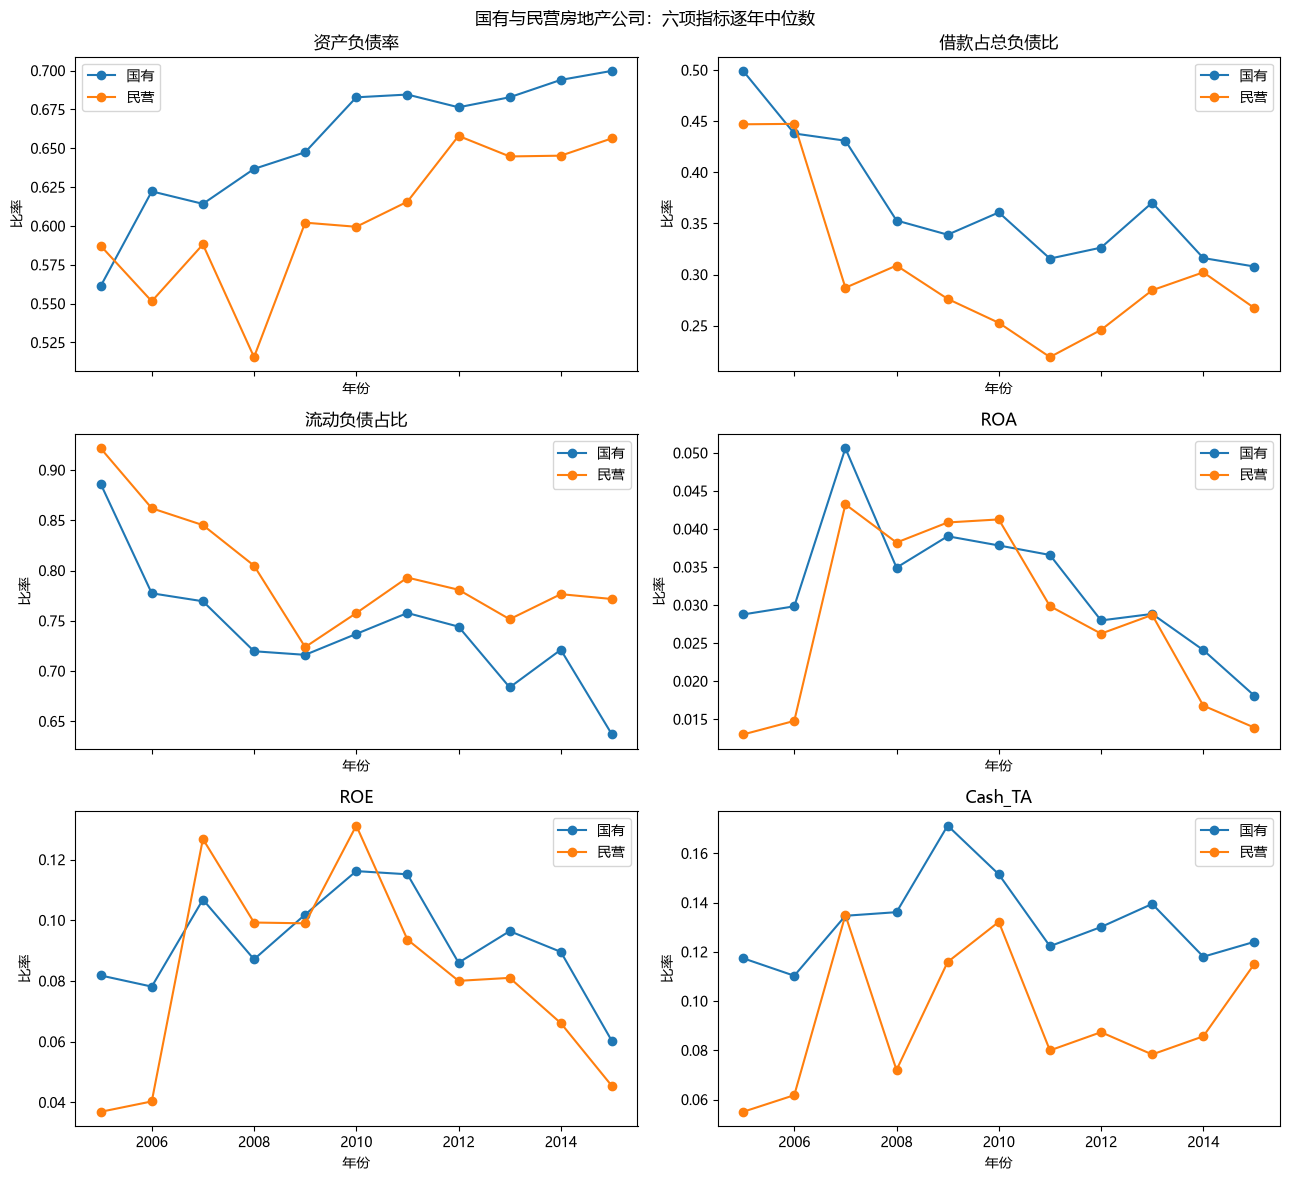

In [4]:
groups = panel[panel.ownership.isin(['国有', '民营'])]
group_mean = groups.groupby(['year', 'ownership'])[list(metrics)].mean()
group_median = groups.groupby(['year', 'ownership'])[list(metrics)].median()
group_n = groups.groupby(['year', 'ownership'])[list(metrics)].count()
display(group_n.rename(columns=metrics))
for stat, frame in [('均值', group_mean), ('中位数', group_median)]:
    fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=True)
    for ax, (key, title) in zip(axes.flat, metrics.items()):
        view = frame[key].unstack('ownership')
        for owner in ['国有', '民营']:
            ax.plot(view.index, view[owner], marker='o', label=owner)
        ax.set(title=title, ylabel='比率', xlabel='年份')
        ax.legend()
    fig.suptitle(f'国有与民营房地产公司：六项指标逐年{stat}')
    fig.tight_layout()
    plt.show()

**结果解读。** 全体企业的资产负债率中位数从 **2005 年约 0.579** 上升到 **2015 年约 0.677**；借款占总负债比的中位数同期从 **0.467** 降至 **0.274**。两者可以同时发生：总负债增多不意味着短、长期借款在负债结构中的份额也上升。ROA 中位数在 2007 年约 0.047，到 2015 年约 0.017；这是描述性变化，不能单独归因于行业政策或产权。

- 各指标有效样本量不同，尤其 ROA 和 ROE 受上年余额及分母限制；年度均值与中位数应对照解读。
- 产权组曲线只说明样本内组间差异；企业规模、杠杆、进入退出与产权变更均可能影响差异，不能作因果解释。

## 4. 缺失、异常值与敏感性检查

**分析思路。** 展示匹配状态、六指标缺失数以及极端观测。保留原始比率用于主结果；另以年度内 1%—99% 截尾均值作敏感性参照，检验极端值是否明显改变均值结论。截尾结果不替代原始值。

In [5]:
merge_columns = [c for c in panel if c.endswith('_merge')]
display(pd.DataFrame({c: panel[c].value_counts() for c in merge_columns}).fillna(0).astype(int))
display(panel[list(metrics)].isna().sum().rename('缺失公司—年度数').to_frame())
display(panel[list(metrics)].quantile([.01, .5, .99]).rename(index={.01: '1%分位', .5: '中位数', .99: '99%分位'}))
print('平均权益≤0:', int((panel.avg_equity <= 0).sum()))
print('资产负债率>1:', int((panel.asset_liability_ratio > 1).sum()))
print('绝对 ROE>1:', int((panel.ROE.abs() > 1).sum()))
trimmed = panel.copy()
for key in metrics:
    lower = trimmed.groupby('year')[key].transform(lambda x: x.quantile(.01))
    upper = trimmed.groupby('year')[key].transform(lambda x: x.quantile(.99))
    trimmed[key] = trimmed[key].clip(lower, upper)
sensitivity = pd.DataFrame({
    '原始均值': panel[list(metrics)].mean(),
    '年度内1%-99%截尾后均值': trimmed[list(metrics)].mean(),
})
display(sensitivity.rename(index=metrics).round(4))

,ownership_merge,balance_merge,lag_merge,borrow_merge,income_merge
both,1176,1176,1166,1176,1176
left_only,0,0,10,0,0


,缺失公司—年度数
asset_liability_ratio,0
bankloan,2
short_liability_share,0
ROA,10
ROE,28
Cash_TA,0


,asset_liability_ratio,bankloan,short_liability_share,ROA,ROE,Cash_TA
1%分位,0.140109,0.000000,0.247524,-0.138150,-0.443038,0.003495
中位数,0.645003,0.317757,0.746821,0.028909,0.087852,0.118011
99%分位,1.162890,0.806108,1.000000,0.189340,0.483266,0.491235


平均权益≤0: 18
资产负债率>1: 19
绝对 ROE>1: 8


,原始均值,年度内1%-99%截尾后均值
资产负债率,0.7011,0.6305
借款占总负债比,0.3251,0.3246
流动负债占比,0.7368,0.7378
ROA,0.0335,0.0321
ROE,0.0871,0.0906
Cash_TA,0.1378,0.1367


**结果解读。** 借款比率缺失 2 条，ROA 缺失 10 条，ROE 缺失 28 条；资产负债率、流动负债占比及现金比率在本次筛选样本中无缺失。ROE 的缺失包含上年余额缺失和非正平均权益。2009 年行业样本的资产负债率均值为 **1.17**，中位数仅 **0.63**；去掉当年一条最极端观测后，均值约 **0.60**。小资产分母及严重资不抵债可能令个别比率异常高，显著拉高算术均值；主结果保留它，同时用中位数及截尾结果提示其影响，而不机械删除。

- 主结果保留原始经济观测；截尾仅作比较，不在原面板中覆写。
- 借款字段缺失不自动视为零借款；公司数量统计不因指标缺失改变。
- `LISTINGSTATE` 缺乏严格历史年末退市时间，完整的生存偏差排除仍有资料限制。

## 5. 总体结论

2005—2015 年样本中房地产 A 股公司数量总体增长，国有份额从约 58% 降至约 46%。典型企业（中位数）的资产负债率上升，而短、长期借款占总负债比下降；ROA 中位数在样本后期低于 2007 年。均值受少数极端公司影响，解读时应优先与中位数、有效样本量及敏感性检查交叉核对。国有和民营差异是描述性关联，不代表产权造成的财务结果。最重要的口径限制是 `bankloan` 使用两项借款余额做代理，可能包含非银行金融机构，以及本次上市状态数据不能独立精确确认历史年末退市日期。

## AI 使用记录

使用 OpenAI Codex 辅助核对 CSMAR 字段、编写 Python 清洗与绘图代码、检查缺失和异常。给 AI 的任务说明（根据实际对话整理，非逐字引述）：“请按 HW02-2 的要求使用 CSMAR 年度合并报表构造房地产 A 股公司面板，计算六项财务指标并核对样本筛选、产权分类、缺失值和极端比率。”初稿核验发现短期借款与长期借款不一定仅来自银行，故将其明确标为 `bankloan` 的代理；还检查了合并匹配、ROA/ROE 有效样本量和极端资产负债率。提交前已本人核验上述判断与结果。